In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
df = pd.read_csv("Deliverable2_cleaned.csv")
df.sample(5)

,X,Y,NCESSCH,STABR,ST_LEAID,LEA_NAME,SCH_NAME,LSTREET1,LCITY,LSTATE,...,STUTERATIO,AM,AS,BL,HP,HI,TR,WH,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
1495,-87.181458,34.205077,10358001463,AL,AL-067,Winston County,Addison Elementary School,16411 County Road 41,Addison,AL,...,17.50,0.000000,0.313480,0.313480,0.000000,0.940439,1.567398,96.865204,True,True
86861,-96.135991,32.892168,483624004075,TX,TX-116908,QUINLAN ISD,WH FORD H S,10064 S BUSINESS 34,QUINLAN,TX,...,14.16,0.254453,0.381679,0.508906,0.127226,39.185751,2.798982,56.743003,True,True
7037,-121.042599,37.664175,60228208409,CA,CA-5030234,Valley Charter High District,Valley College High,2209 Blue Gum Rd.,Modesto,CA,...,12.21,0.000000,2.702703,6.756757,0.000000,54.054054,6.756757,28.378378,False,True
51582,-111.170489,45.675823,301875000585,MT,MT-0363,Monforton Elem,Monforton School,6001 Monforton School Rd,Bozeman,MT,...,14.42,1.351351,1.351351,0.000000,0.900901,2.702703,2.702703,90.990991,True,True
40124,-71.110807,41.733420,250483001780,MA,MA-0095,Fall River,North End Elementary,1899 Meridan Street,Fall River,MA,...,14.16,0.000000,3.056769,20.378457,0.000000,20.087336,3.639010,52.838428,True,True


## 1. Identify Problem Type and Variables

Our target is Student Teacher Ratio "STUTERATIO", which is a continuous value. That make our data a regression problem.

In [2]:
# Sepearte Target and others
# 1. Isolate the features (all columns except STUTERATIO)
X = df.drop(columns=['STUTERATIO'])

# 2. Isolate the target variable
Y = df['STUTERATIO']

Y.dtype
X.TOTAL_RACE_CONS.dtype

dtype('bool')

## 2. Feature Selection

### Preparation

In [3]:
# Convert categorical ones to labels
## Split the two types of columns
X['LZIP'] = X['LZIP'].astype(str)
categorical_cols = X.select_dtypes(include=['object', 'bool'])
numerical_cols = X.select_dtypes(include=['number'])

print(f"Categorical Features: {categorical_cols.columns}")
print(f"Numerical Features: {numerical_cols.columns}")

## Label with the ones need to convert and then store the mapping in a dictionary
from sklearn.preprocessing import LabelEncoder

# 1. Use the list you manually defined
need_convert_cols = [
    'STABR', 'LSTATE', 'VIRTUAL', 'GSLO', 'GSHI', 'SCHOOL_LEVEL',
    'SCHOOL_TYPE_TEXT', 'SY_STATUS_TEXT', 'ULOCALE', 
    'TOTAL_RACE_CONS', 'TOTAL_GRADE_CONS']

label_encoders = {}
encoding_mapping = {}

# 2. Loop directly through your defined list
for col in need_convert_cols:
    # Safety check: make sure the column actually exists in df
    if col in X.columns:
        le = LabelEncoder()
        
        # Convert to string to handle any mixed types or NaNs gracefully
        X[col] = le.fit_transform(X[col].astype(str))
        
        # Store the encoder object
        label_encoders[col] = le
        
        # Store the human-readable mapping
        encoding_mapping[col] = dict(zip(le.classes_, range(len(le.classes_))))
    else:
        print(f"Warning: {col} not found in DataFrame.")


# constant drop
# from sklearn.feature_selection import VarianceThreshold
# constant_threshold = 0.2
# num_df = s.select_dtypes(include='number')
# selector = VarianceThreshold(constant_threshold)
# selector.fit(num_df)
# kept_cols = num_df.columns[selector.get_support()]
# constant_cols = num_df.columns[~selector.get_support()]

# print("Constant columns:", list(constant_cols))

Categorical Features: Index(['STABR', 'ST_LEAID', 'LEA_NAME', 'SCH_NAME', 'LSTREET1', 'LCITY',
       'LSTATE', 'LZIP', 'PHONE', 'VIRTUAL', 'GSLO', 'GSHI', 'SCHOOL_LEVEL',
       'SCHOOL_TYPE_TEXT', 'SY_STATUS_TEXT', 'ULOCALE', 'NMCNTY',
       'TOTAL_RACE_CONS', 'TOTAL_GRADE_CONS'],
      dtype='object')
Numerical Features: Index(['X', 'Y', 'NCESSCH', 'TOTFRL', 'REDLCH', 'PK', 'G01', 'G03', 'G05',
       'G06', 'G08', 'G11', 'G13', 'UG', 'AE', 'TOTMENROL', 'TOTFENROL', 'AM',
       'AS', 'BL', 'HP', 'HI', 'TR', 'WH'],
      dtype='object')


In [4]:
## Example: Peek at the mapping
print("STABR Mapping:", encoding_mapping.get('STABR', 'Not found'))
print("STABR Mapping:", encoding_mapping.get('VIRTUAL', 'Not found'))
print("STABR Mapping:", encoding_mapping.get('GSLO', 'Not found'))
print("STABR Mapping:", encoding_mapping.get('TOTAL_RACE_CONS', 'Not found'))
X.sample()

STABR Mapping: {'AK': 0, 'AL': 1, 'AR': 2, 'AZ': 3, 'CA': 4, 'CO': 5, 'CT': 6, 'DC': 7, 'DE': 8, 'FL': 9, 'GA': 10, 'HI': 11, 'IA': 12, 'ID': 13, 'IL': 14, 'IN': 15, 'KS': 16, 'KY': 17, 'LA': 18, 'MA': 19, 'MD': 20, 'ME': 21, 'MI': 22, 'MN': 23, 'MO': 24, 'MP': 25, 'MS': 26, 'MT': 27, 'NC': 28, 'ND': 29, 'NE': 30, 'NH': 31, 'NJ': 32, 'NM': 33, 'NV': 34, 'NY': 35, 'OH': 36, 'OK': 37, 'OR': 38, 'PA': 39, 'PR': 40, 'RI': 41, 'SC': 42, 'SD': 43, 'TN': 44, 'TX': 45, 'UT': 46, 'VA': 47, 'VI': 48, 'VT': 49, 'WA': 50, 'WI': 51, 'WV': 52, 'WY': 53}
STABR Mapping: {'Full Virtual': 0, 'Missing': 1, 'Not Virtual': 2, 'Supplemental Virtual': 3, 'Virtual with face to face options': 4}
STABR Mapping: {'01': 0, '02': 1, '03': 2, '04': 3, '05': 4, '06': 5, '07': 6, '08': 7, '09': 8, '10': 9, '11': 10, '12': 11, 'KG': 12, 'PK': 13, 'UG': 14}
STABR Mapping: {'False': 0, 'True': 1}


,X,Y,NCESSCH,STABR,ST_LEAID,LEA_NAME,SCH_NAME,LSTREET1,LCITY,LSTATE,...,TOTFENROL,AM,AS,BL,HP,HI,TR,WH,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
2444,-112.221462,33.425602,40046303761,3,AZ-6393,Arizona State Schools for the Deaf and the Bli...,ASDB - ELP FBC West Valley Preschool,2430 S 75TH AVE,PHOENIX,3,...,66.666667,0.0,0.0,0.0,0.0,66.666667,0.0,33.333333,1,1


### a. Dropping constant or qasi-constant input features (notes from Module 5).
### b. Dropping highly correlated, i.e., redundant input features (notes from Module 5).
### c. Information Gain / Mutual Information for regression (notes from Module 8).

In [5]:
## a. Dropping constant

from sklearn.feature_selection import VarianceThreshold

# Combine your encoded cats and your numbers
X_for_testing = X[need_convert_cols + list(numerical_cols.columns)]

# Set a lower threshold for encoded/binary data (e.g., 0.01)
# 0.01 means we drop features where ~99% of values are the same
selector = VarianceThreshold(threshold=0.01) 

selector.fit(X_for_testing)

# Get the results
kept_cols = X_for_testing.columns[selector.get_support()]
constant_cols = X_for_testing.columns[~selector.get_support()]

print("Features dropped due to low variance:", list(constant_cols))
print(f"Features kept: {len(kept_cols)}")


Features dropped due to low variance: ['TOTAL_GRADE_CONS']
Features kept: 34


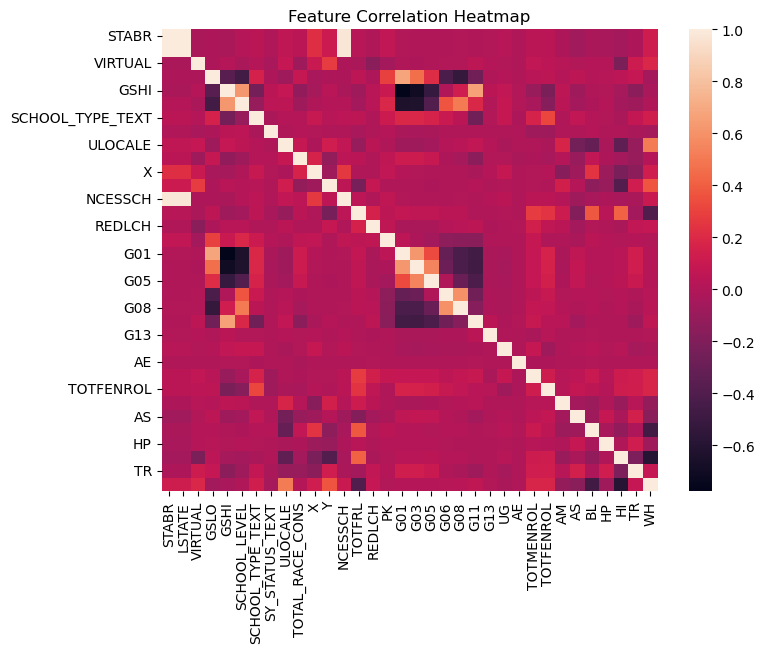

Correlated Pairs: [('LSTATE', 'STABR', np.float64(1.0)), ('NCESSCH', 'STABR', np.float64(0.9765106859420187)), ('NCESSCH', 'LSTATE', np.float64(0.9765106859420187)), ('G01', 'GSHI', np.float64(-0.7765698027607355))]
Removing COlumns: ['STABR', 'NCESSCH', 'G01']
Kept Columns Lenth: 31
Saved P2_Deliverable1_cleaned.csv


In [6]:
## b. Dropping highly correlated

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
fig.set_size_inches(8,6)
sns.heatmap(X[kept_cols].corr())
plt.title("Feature Correlation Heatmap")
plt.show()

def find_correlated_pairs(dataset, threshold=0.7):
    corr_matrix = dataset.corr()
    correlated_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > threshold:
                correlated_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
                
    return correlated_pairs

# Find correlated pairs
correlated_pairs = find_correlated_pairs(X[kept_cols], threshold=0.7)
print("Correlated Pairs:", list(correlated_pairs))
remove_cols = ['STABR', 'NCESSCH', 'G01']
print("Removing COlumns:", remove_cols)

kept_cols = kept_cols.difference(remove_cols)

print("Kept Columns Lenth:", len(kept_cols))

### Store the data
cleaned_df = pd.concat([X[kept_cols], Y], axis=1)
cleaned_df.to_csv("P2_Deliverable1_cleaned.csv", index=False)
print("Saved P2_Deliverable1_cleaned.csv")

After identifying correlated pairs, NCESSCH, STABR and G01 were also removed based on usefulness and interpretability. NCESSCH was removed because it is just a unique identifier and does not contribute meaningful information for prediction. STABR was also removed because it represents a categorical location variable and does not provide useful numeric information in the context of STUTERATIO. G01 was removed because it is highly correlated with other enrollment/totals so it does not add additional predictive value.

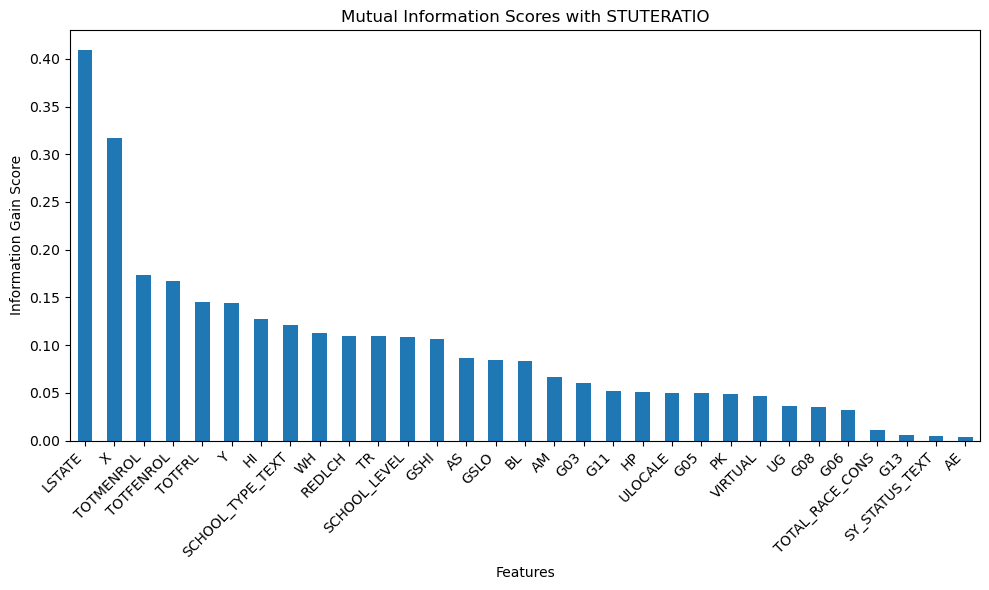

In [7]:
## c. Information Gain / Mutual Information for regression

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression

X_mi = X[kept_cols]
y_mi = Y

X_train,X_test,y_train,y_test=train_test_split(X_mi,y_mi,test_size=0.3,random_state=3)

categorical_mask = [col in need_convert_cols for col in kept_cols]
mi_scores = mutual_info_regression(X_train, y_train, discrete_features=categorical_mask, random_state=42)
mi_results = pd.Series(mi_scores, name="MI Scores", index=kept_cols)
mi_results = mi_results.sort_values(ascending=False)

## plotting
plt.figure(figsize=(10, 6))
mi_results.plot(kind='bar')

plt.title("Mutual Information Scores with STUTERATIO")
plt.ylabel("Information Gain Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
## Keeping features over 0.10

# Create a list of columns where the score is > 0.10
top_mi_cols = mi_results[mi_results > 0.10].index.tolist()

print(f"Columns with MI > 0.10: {top_mi_cols}")
print(f"Count: {len(top_mi_cols)} columns kept.")

## Update Training and Testing Sets
X_train_final = X_train[top_mi_cols]
X_test_final = X_test[top_mi_cols]

Columns with MI > 0.10: ['LSTATE', 'X', 'TOTMENROL', 'TOTFENROL', 'TOTFRL', 'Y', 'HI', 'SCHOOL_TYPE_TEXT', 'WH', 'REDLCH', 'TR', 'SCHOOL_LEVEL', 'GSHI']
Count: 13 columns kept.


A threshold of 0.1 was used to select features. Features with mutual information scores below 0.1 were considered to have very weak relationships with the target variable and were therefore removed. These features contribute little predictive value and may introduce noise into the model.

The threshold of 0.1 was chosen to strike a balance between retaining meaningful predictors and removing irrelevant features. Lower thresholds would retain too many weak features, while higher thresholds could eliminate useful information.

By keeping only features with higher mutual information scores, the model focuses on variables that have a stronger influence on student-teacher ratio, improving overall model performance and interpretability.

The distribution of mutual information scores showed a natural separation between low-scoring and higher-scoring features at 0.1, supporting the use of this threshold.

## 3. Model Building

### Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train)
lin_predictions = lin_reg.predict(X_test_final)
lin_r2 = r2_score(y_test, lin_predictions)

n = X_test_final.shape[0]
k = X_test_final.shape[1]

lin_adj_r2 = 1 - ((1 - lin_r2) * (n - 1) / (n - k - 1))


print("MSE:", mean_squared_error(y_test, lin_predictions))
print("R2 Score:", lin_r2)
print("Adjusted R2:", lin_adj_r2)

MSE: 27.742495101467696
R2 Score: 0.16837719387021477
Adjusted R2: 0.1680117936444505


### Decision Tree Regressor


In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the model
# 'max_depth' prevents the tree from growing too complex (overfitting)
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

# 2. Train the model
tree_reg.fit(X_train_final, y_train)

# 3. Make predictions
tree_predictions = tree_reg.predict(X_test_final)

# 4. Evaluate
tree_r2 = r2_score(y_test, tree_predictions)

n = X_test_final.shape[0]
k = X_test_final.shape[1]

tree_adj_r2 = 1 - ((1 - tree_r2) * (n - 1) / (n - k - 1))


print("MSE:", mean_squared_error(y_test, tree_predictions))
print("R2 Score:", tree_r2)
print("Adjusted R2:", tree_adj_r2)


MSE: 24.773246878584374
R2 Score: 0.25738485270474665
Adjusted R2: 0.25705856085647416


### Random Forest Regressor


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the model
# n_estimators is the number of trees. 100 is a solid default.
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# 2. Train the model
rf_reg.fit(X_train_final, y_train)

# 3. Make predictions
rf_predictions = rf_reg.predict(X_test_final)

# 4. Evaluate
rf_r2 = r2_score(y_test, rf_predictions)

n = X_test_final.shape[0]
k = X_test_final.shape[1]

rf_adj_r2 = 1 - ((1 - rf_r2) * (n - 1) / (n - k - 1))

print("MSE:", mean_squared_error(y_test, rf_predictions))
print("R2 Score:", rf_r2)
print("Adjusted R2:", rf_adj_r2)

MSE: 20.3773305128865
R2 Score: 0.38915902406830605
Adjusted R2: 0.3888906314402223


### Support Vector Regressor (SVR)

In [18]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# X_sample, _, y_sample, _ = train_test_split(
#     X_train_final, y_train, train_size=50000, random_state=42
# )

# # Run the SVR on the sample
# svr_sample = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0))
# svr_sample.fit(X_sample, y_sample)

# svr_predictions = svr_sample.predict(X_test_final)

# # 4. Evaluate
# svr_r2 = r2_score(y_test, svr_predictions)

# n = X_test_final.shape[0]
# k = X_test_final.shape[1]

# svr_adj_r2 = 1 - ((1 - rf_r2) * (n - 1) / (n - k - 1))

# print("SVR MSE:", mean_squared_error(y_test, svr_predictions))
# print("SVR R2 Score:", svr_r2)
# print("Adjusted R2:", svr_adj_r2)


# 1. Initialize the model with a Pipeline
# Scaling is CRITICAL for SVR performance
svr_reg = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, epsilon=0.1, cache_size=1000))

# 2. Train the model
svr_reg.fit(X_train_final, y_train)

# 3. Make predictions
svr_predictions = svr_reg.predict(X_test_final)

# 4. Evaluate
svr_r2 = r2_score(y_test, svr_predictions)

n = X_test_final.shape[0]
k = X_test_final.shape[1]

svr_adj_r2 = 1 - ((1 - svr_r2) * (n - 1) / (n - k - 1))

print("SVR MSE:", mean_squared_error(y_test, svr_predictions))
print("SVR R2 Score:", svr_r2)
print("Adjusted R2:", svr_adj_r2)

SVR MSE: 22.092720448910246
SVR R2 Score: 0.33773764372795634
Adjusted R2: 0.3374466574626528


## 4. Model Evaluation and Interpretation

#### Choice of Metrics

###### Why Adjusted $R^2$ is the Superior Metric

Adjusted $R^2$ was chosen as the primary evaluation metric because it provides a more reliable measure of model performance when multiple features are used. Unlike standard $R^2$, which always increases as more variables are added, Adjusted $R^2$ penalizes unnecessary features. This helps prevent overfitting and ensures that only meaningful predictors improve the model. It also allows for fair comparison between simple models, such as Linear Regression, and more complex models like Random Forest, which use many internal decision rules.

Feature Penalty: Standard $R^2$ mathematically must increase (or stay the same) every time you add a new variable, even if that variable is just random noise. Adjusted $R^2$ incorporates a penalty for the number of predictors ($k$).

Preventing Overfitting: It tells you if the complexity of your model is actually adding value. If Adjusted $R^2$ is significantly lower than $R^2$, it’s a red flag that your model is "bloated" with useless features.

Comparability: It allows you to fairly compare a simple model (Linear Regression) against a complex one (Random Forest) by accounting for the degrees of freedom used by each.

#### Summary Table


|**Model**|**Adjusted R2 Score**|**Interpretation**|**Rank**|
|---|---|---|---|
|**Random Forest**|**0.3889**|**Strongest Fit**|**1st**|
|**SVR (Sampled)**|0.3374|Moderate Fit|2nd|
|**Decision Tree**|0.2571|Weak/Moderate Fit|3rd|
|**Linear Regression**|0.1680|Weak Fit|4th|

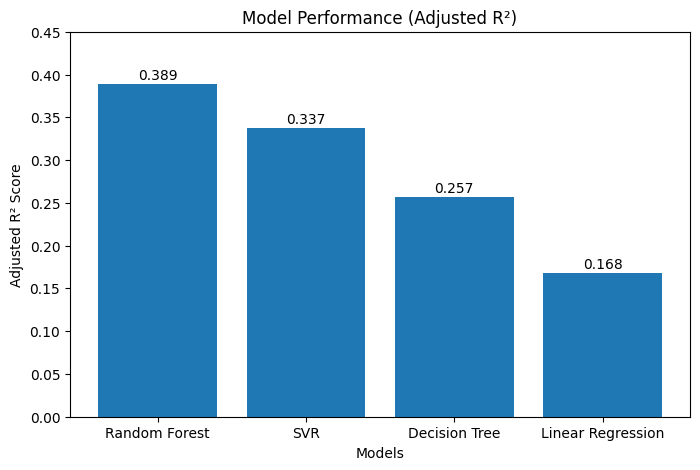

In [2]:
import matplotlib.pyplot as plt

# Model names and scores
models = ["Random Forest", "SVR", "Decision Tree", "Linear Regression"]
scores = [0.3889, 0.3374, 0.2571, 0.1680]

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)

# Labels
plt.title("Model Performance (Adjusted R²)")
plt.ylabel("Adjusted R² Score")
plt.xlabel("Models")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.3f}", ha='center')

plt.ylim(0, 0.45)
plt.show()

Among the models tested, Random Forest achieved the highest Adjusted $R^2$ score (0.3889), making it the best-performing model. This was followed by SVR (0.3374), Decision Tree (0.2571), and then Linear Regression (0.1680).


### Why Random Forest Performed Best
Random Forest performed the best because it is able to capture complex, non-linear relationships in the data. 

The large improvement from Linear Regression (0.1680) to Random Forest (0.3889) suggests that the relationship between the features and student-teacher ratio is not purely linear.

Because Random Forest works by combining multiple decision trees, it allows for modelling interactions between variables more effectively, and reduces overfitting by averaging the results of many trees, making it more stable than a single decision tree.

### At approximately 40% Accuracy, why are the models (moderately) inaccurate?

Although Random Forest performed the best, the overall model performance is still moderate, with an Adjusted $R^2$ of 0.3889. This means that the model is only able to explain about 39% of the variation in student-teacher ratio, while the remaining variation is influenced by factors not captured in the dataset.

#### Missing Variables
One major limitation is that the dataset does not include all variables that influence student-teacher ratio. While the dataset contains demographic and structural information such as enrollment, race composition, and school type, it does not include important real-world factors like school funding, teacher availability, district policies, or budget allocation.

These missing variables likely play a significant role in determining class size. Because the model does not have access to this information, it cannot fully explain the variation in the target variable, which reduces overall accuracy.

#### No Hyperparameter Tuning
Another reason for the moderate accuracy is that all models were evaluated using default parameters, as required for baseline performance. Each machine learning model has hyperparameters that control how it learns patterns in the data.

For example, in a Random Forest model, parameters such as the number of trees, tree depth, and minimum samples per split determine how complex or flexible the model is. If the trees are too shallow, the model might underfit and miss important patterns. If they are too deep, the model may overfit and focus too much on noise in the training data.

Default parameters are settings that are not tailored to this specific dataset. Without tuning these parameters, the model is not optimized, which limits how well it predicts.

#### Real-World Data Noise/Variability
Another reason behind the moderate accuracy is simply due to the fact that we're using real world data. Because this is real world, it is impossible to avoid contain noise and variability, which makes prediction more difficult. In this dataset, schools with similar characteristics most likely still have very different student-teacher ratios from factors that are not recorded, like administrative decisions, local policies, or unexpected staffing changes. This means that even if two schools look similar based on the available features, their outcomes may still differ. Because of all of this, the model cannot learn a consistent pattern for these cases, which does affect its ability to make accurate predictions about them.

#### Relationship Complexity/Non-Linear Relationships
Finally, the relationship between the input features and the student-teacher ratio is most complex and non-linear. While models like Random Forest can capture some of these patterns, simpler models such as Linear Regression can't.

Even with more advanced models, some relationships involve interactions between multiple variables that are difficult to fully capture without additional feature engineering or tuning. This limits how well the models can represent the true underlying patterns in the data. In the current state of our analysis, we may need to undertake more significant feature engineering to better discover and represent patterns not seen with the current analysis that we have.

#### How does the model compare to real world analytics? Is this result viable?
The predictive performance of the model is influenced by the nature of the dataset, which represents a real-world educational system. Student–teacher ratio is not determined solely by the variables included in the dataset, such as enrollment, demographics, or school type. It is also heavily affected by external factors that are not captured in the data. These include funding levels, teacher hiring decisions, district and provincial policies, class size regulations, and overall resource allocation.

Many of these factors are driven by human decision-making rather than fixed mathematical relationships. Factors such as Administrative policies, budgeting decisions, and staffing strategies introduce variability that cannot be fully captured by the available features in this specific dataset. As a result, even if we were to design extremely well designed models, they would still be limited in their ability to explain all variation in the target variable because of the human factor in this context.

From research: this limitation is common in social science and education data. Unlike controlled environments such as engineering or physics, where relationships are more predictable, educational outcomes are influenced by complex and often unobserved factors. Based on typical findings in these fields, it is common for models to achieve $R^2$ values in the range to be low to moderate. Human behavioural fields are more likely to have $R^2$ values lower than 50% and values in the range of 0.1 to 0.5 are reasonable. 

Therefore, an adjusted $R^2$ of around 0.4 in this project can be considered a meaningful result. It indicates that the model is able to capture important patterns in the data, but realizing the affect of the data we have and how the model performs shows us the complexity and variability of real-world educational systems.

Sources:
- https://people.duke.edu/~rnau/rsquared.htm
- https://mpra.ub.uni-muenchen.de/115769/1/MPRA_paper_115769.pdf
- https://blog.minitab.com/en/blog/adventures-in-statistics-2/regression-analysis-how-do-i-interpret-r-squared-and-assess-the-goodness-of-fit